# ✈️ Flight Delay Predictor

## End-to-End Machine Learning Project

### Objective
Build a machine learning model that predicts whether a flight will be delayed using:

- Flight operational data
- Airline information
- Airport information
- Historical weather data

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-Learn
- XGBoost
- Streamlit

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================

RANDOM_STATE = 42
SAMPLE_SIZE = 300_000

DATA_PATH = Path("../data")

print("Random State :", RANDOM_STATE)
print("Sample Size  :", f"{SAMPLE_SIZE:,}")
print("Data Path    :", DATA_PATH)

Random State : 42
Sample Size  : 300,000
Data Path    : ..\data


In [4]:
# ============================================================
# 3. CHECK DATA FILES
# ============================================================

data_files = sorted(DATA_PATH.glob("*.csv"))

print(f"CSV files found: {len(data_files)}\n")

for file in data_files:
    print(file.name)

CSV files found: 10

airlines.csv
airports.csv
city_attributes.csv
flights.csv
humidity.csv
pressure.csv
temperature.csv
weather_description.csv
wind_direction.csv
wind_speed.csv


In [5]:
# ============================================================
# 4. LOAD SUPPORTING DATASETS
# ============================================================

airlines = pd.read_csv(DATA_PATH / "airlines.csv")
airports = pd.read_csv(DATA_PATH / "airports.csv")

temperature = pd.read_csv(DATA_PATH / "temperature.csv")
humidity = pd.read_csv(DATA_PATH / "humidity.csv")
pressure = pd.read_csv(DATA_PATH / "pressure.csv")
wind_speed = pd.read_csv(DATA_PATH / "wind_speed.csv")
weather_description = pd.read_csv(
    DATA_PATH / "weather_description.csv"
)

print("Supporting datasets loaded successfully!\n")

print("Airlines            :", airlines.shape)
print("Airports             :", airports.shape)
print("Temperature          :", temperature.shape)
print("Humidity             :", humidity.shape)
print("Pressure             :", pressure.shape)
print("Wind Speed           :", wind_speed.shape)
print("Weather Description  :", weather_description.shape)

Supporting datasets loaded successfully!

Airlines            : (14, 2)
Airports             : (322, 7)
Temperature          : (45253, 37)
Humidity             : (45253, 37)
Pressure             : (45253, 37)
Wind Speed           : (45253, 37)
Weather Description  : (45253, 37)


In [6]:
# ============================================================
# 5. LOAD FLIGHT DATA
# ============================================================

print("Loading flights.csv...")

flights = pd.read_csv(DATA_PATH / "flights.csv")

print("Full flight dataset:", flights.shape)

df = flights.sample(
    n=min(SAMPLE_SIZE, len(flights)),
    random_state=RANDOM_STATE
).copy()

df.reset_index(drop=True, inplace=True)

print("\nWorking dataset:", df.shape)

Loading flights.csv...
Full flight dataset: (5819079, 31)

Working dataset: (300000, 31)


In [7]:
# Remove the full dataset from memory
del flights

import gc
gc.collect()

print("Full flights dataset removed from memory.")
print("Working dataset:", df.shape)

Full flights dataset removed from memory.
Working dataset: (300000, 31)


In [8]:
# ============================================================
# 6. INITIAL DATA CHECK
# ============================================================

display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Columns:")
print(len(df.columns))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,1423.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,2133.0,-12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,812.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,1222.0,152.0,0,0,NaN,0.0,0.0,0.0,152.0,0.0
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,1316.0,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



Dataset Shape:
(300000, 31)

Number of Columns:
31

Duplicate Rows:
0


# 2. Data Understanding and Cleaning

Before building the prediction model, the flight dataset is inspected for data types, missing values, cancellations, diversions, and other data-quality issues.

Flights that were cancelled or diverted are removed because the objective is to predict delays for flights that actually operated.

In [9]:
# ============================================================
# 7. DATASET INFORMATION
# ============================================================

print("Dataset Shape:", df.shape)
print("\nDataset Information:\n")

df.info()

Dataset Shape: (300000, 31)

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 300000 non-null  int64  
 1   MONTH                300000 non-null  int64  
 2   DAY                  300000 non-null  int64  
 3   DAY_OF_WEEK          300000 non-null  int64  
 4   AIRLINE              300000 non-null  str    
 5   FLIGHT_NUMBER        300000 non-null  int64  
 6   TAIL_NUMBER          299241 non-null  str    
 7   ORIGIN_AIRPORT       300000 non-null  object 
 8   DESTINATION_AIRPORT  300000 non-null  object 
 9   SCHEDULED_DEPARTURE  300000 non-null  int64  
 10  DEPARTURE_TIME       295606 non-null  float64
 11  DEPARTURE_DELAY      295606 non-null  float64
 12  TAXI_OUT             295456 non-null  float64
 13  WHEELS_OFF           295456 non-null  float64
 14  SCHEDULED_TIME       300000 

In [10]:
# ============================================================
# 8. MISSING VALUE ANALYSIS
# ============================================================

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing_Count"] > 0]
missing = missing.sort_values("Missing_Percentage", ascending=False)

missing

,Missing_Count,Missing_Percentage
CANCELLATION_REASON,295415,98.47
AIR_SYSTEM_DELAY,245054,81.68
SECURITY_DELAY,245054,81.68
WEATHER_DELAY,245054,81.68
AIRLINE_DELAY,245054,81.68
LATE_AIRCRAFT_DELAY,245054,81.68
ARRIVAL_DELAY,5322,1.77
AIR_TIME,5322,1.77
ELAPSED_TIME,5322,1.77
WHEELS_ON,4715,1.57


In [11]:
# ============================================================
# 9. CANCELLATIONS AND DIVERSIONS
# ============================================================

print("Total flights:", len(df))

print(
    "Cancelled flights:",
    int(df["CANCELLED"].sum())
)

print(
    "Diverted flights:",
    int(df["DIVERTED"].sum())
)

Total flights: 300000
Cancelled flights: 4585
Diverted flights: 737


In [12]:
# Keep only flights that actually completed normally

df = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0)
].copy()

df.reset_index(drop=True, inplace=True)

print("Dataset after removing cancelled/diverted flights:")
print(df.shape)

Dataset after removing cancelled/diverted flights:
(294678, 31)


In [13]:
# ============================================================
# 10. REMOVE UNUSED / LEAKAGE COLUMNS
# ============================================================

columns_to_drop = [
    "CANCELLED",
    "CANCELLATION_REASON",
    "DIVERTED",

    # Information only known during/after the flight
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "TAXI_OUT",
    "WHEELS_OFF",
    "ELAPSED_TIME",
    "AIR_TIME",
    "WHEELS_ON",
    "TAXI_IN",
    "ARRIVAL_TIME",

    # Delay-cause information known after a delay occurs
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

print("Remaining columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Remaining columns: 14

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']


In [14]:
# ============================================================
# 11. CREATE TARGET VARIABLE
# ============================================================

df = df.dropna(subset=["ARRIVAL_DELAY"]).copy()

df["DELAYED"] = (
    df["ARRIVAL_DELAY"] >= 15
).astype(int)

print("Target distribution:\n")

print(df["DELAYED"].value_counts())

print("\nTarget percentages:\n")

print(
    (df["DELAYED"].value_counts(normalize=True) * 100)
    .round(2)
)

Target distribution:

DELAYED
0    239732
1     54946
Name: count, dtype: int64

Target percentages:

DELAYED
0    81.35
1    18.65
Name: proportion, dtype: float64


In [15]:
df.drop(
    columns=["ARRIVAL_DELAY"],
    inplace=True
)

print("ARRIVAL_DELAY present:",
      "ARRIVAL_DELAY" in df.columns)

print("DELAYED present:",
      "DELAYED" in df.columns)

print("\nFinal shape after initial cleaning:")
print(df.shape)

ARRIVAL_DELAY present: False
DELAYED present: True

Final shape after initial cleaning:
(294678, 14)


# 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of flight delays and identify patterns associated with airlines, airports, time periods, and flight distance.

Because the target variable is imbalanced, model performance will later be evaluated using precision, recall, F1-score, and ROC-AUC in addition to accuracy.

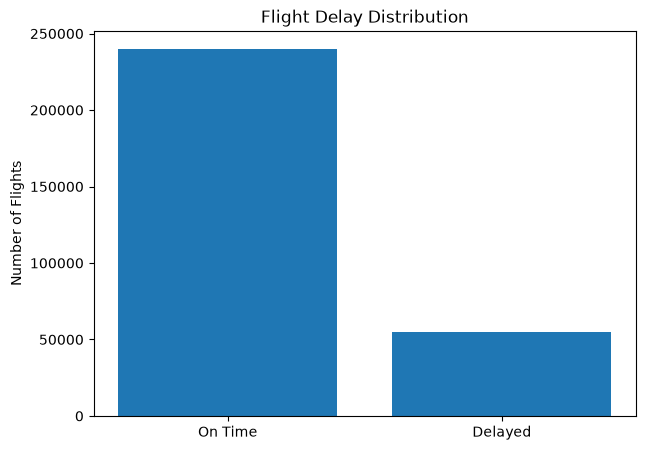

DELAYED
0    81.35
1    18.65
Name: proportion, dtype: float64


In [16]:
# ============================================================
# 12. TARGET DISTRIBUTION
# ============================================================

target_counts = df["DELAYED"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["On Time", "Delayed"],
    target_counts.values
)

plt.title("Flight Delay Distribution")
plt.ylabel("Number of Flights")

plt.show()

print(
    (df["DELAYED"].value_counts(normalize=True) * 100)
    .round(2)
)

,AIRLINE,count,Delay_Rate
8,NK,5989,28.986475
5,F9,4569,25.979427
2,B6,13364,22.837474
7,MQ,14450,21.598616
10,UA,26190,20.286369
4,EV,28547,19.536203
13,WN,64158,19.266498
9,OO,29734,18.924464
12,VX,3124,18.918054
0,AA,36933,18.514608


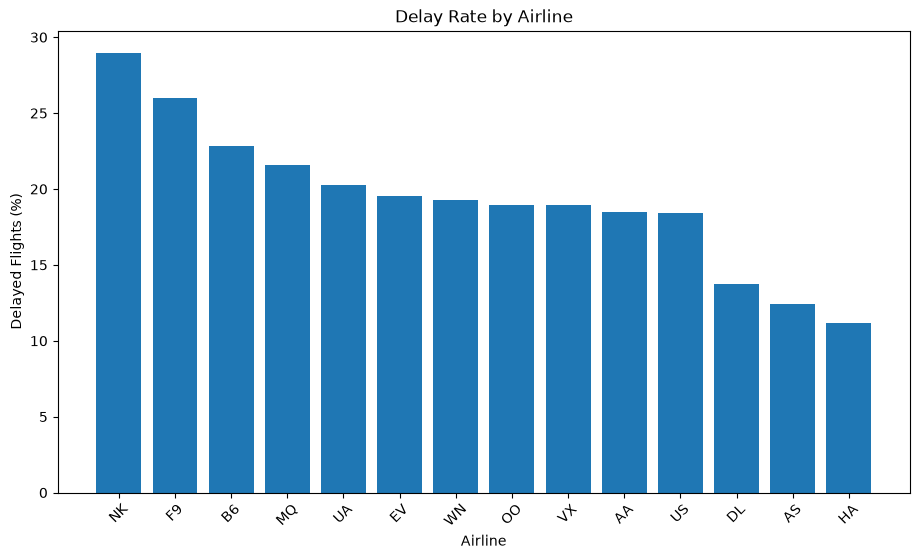

In [17]:
# ============================================================
# 13. DELAY RATE BY AIRLINE
# ============================================================

airline_delay = (
    df.groupby("AIRLINE")["DELAYED"]
    .agg(["mean", "count"])
    .reset_index()
)

airline_delay["Delay_Rate"] = airline_delay["mean"] * 100

airline_delay = airline_delay.sort_values(
    "Delay_Rate",
    ascending=False
)

display(
    airline_delay[
        ["AIRLINE", "count", "Delay_Rate"]
    ]
)

plt.figure(figsize=(11, 6))

plt.bar(
    airline_delay["AIRLINE"],
    airline_delay["Delay_Rate"]
)

plt.title("Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=45)

plt.show()

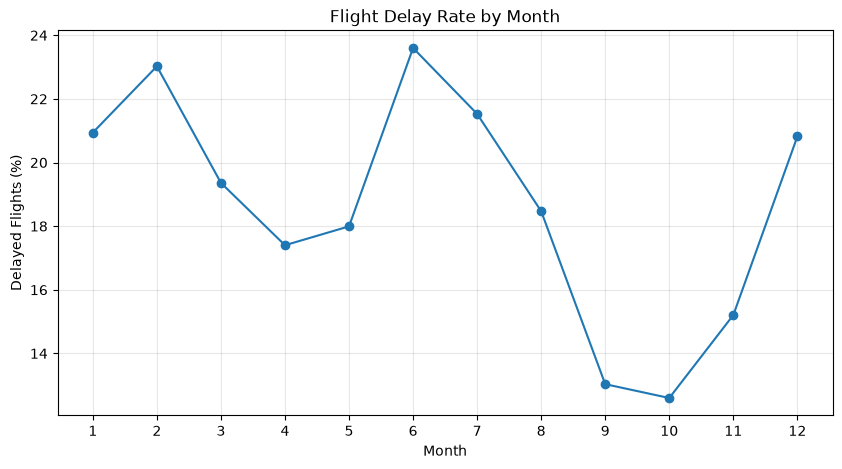

MONTH
1     20.94
2     23.02
3     19.36
4     17.40
5     17.99
6     23.60
7     21.53
8     18.47
9     13.03
10    12.60
11    15.21
12    20.82
Name: DELAYED, dtype: float64

In [18]:
# ============================================================
# 14. MONTHLY DELAY PATTERN
# ============================================================

monthly_delay = (
    df.groupby("MONTH")["DELAYED"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_delay.index,
    monthly_delay.values,
    marker="o"
)

plt.title("Flight Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delayed Flights (%)")

plt.xticks(range(1, 13))

plt.grid(alpha=0.3)

plt.show()

display(monthly_delay.round(2))

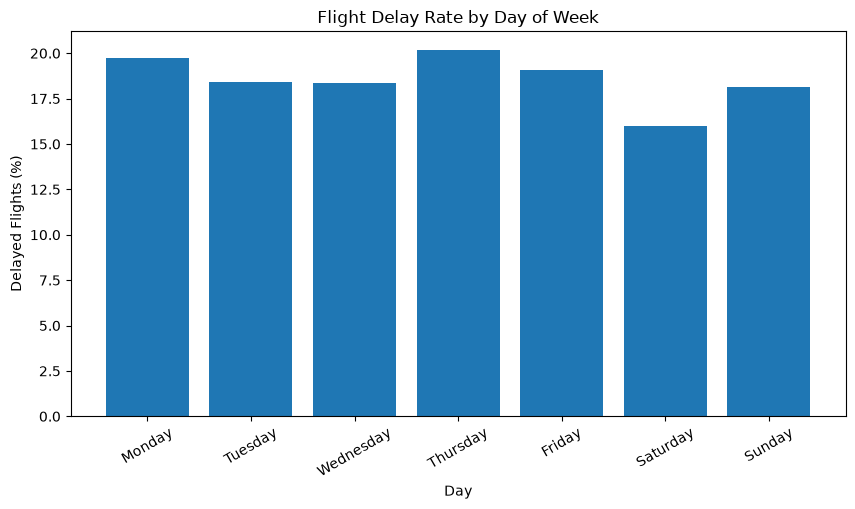

DAY_OF_WEEK
Monday       19.74
Tuesday      18.43
Wednesday    18.37
Thursday     20.20
Friday       19.10
Saturday     15.99
Sunday       18.15
Name: DELAYED, dtype: float64

In [19]:
# ============================================================
# 15. DELAY RATE BY DAY OF WEEK
# ============================================================

day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

dow_delay = (
    df.groupby("DAY_OF_WEEK")["DELAYED"]
    .mean()
    .mul(100)
)

dow_delay.index = dow_delay.index.map(day_names)

plt.figure(figsize=(10, 5))

plt.bar(
    dow_delay.index,
    dow_delay.values
)

plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=30)

plt.show()

display(dow_delay.round(2))

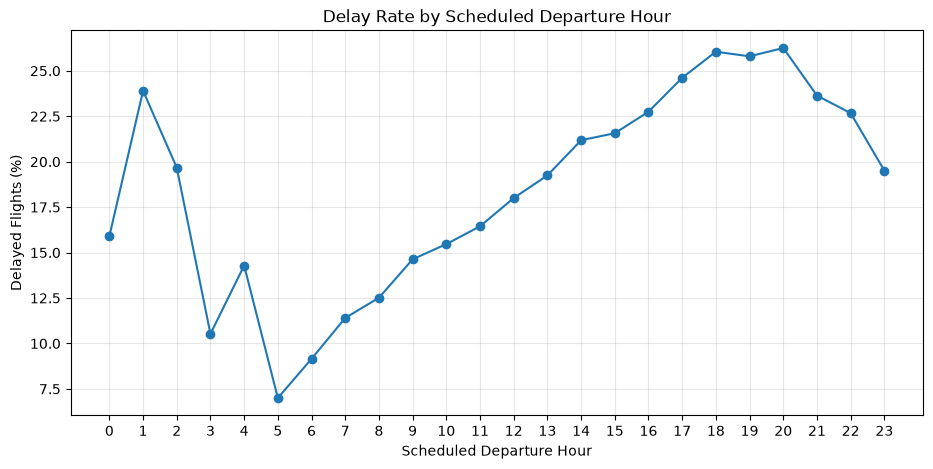

In [20]:
# ============================================================
# 16. SCHEDULED DEPARTURE HOUR ANALYSIS
# ============================================================

df["Departure_Hour"] = (
    df["SCHEDULED_DEPARTURE"] // 100
).astype(int)

# Safety check for unusual HHMM values
df["Departure_Hour"] = df["Departure_Hour"].clip(0, 23)

hourly_delay = (
    df.groupby("Departure_Hour")["DELAYED"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(11, 5))

plt.plot(
    hourly_delay.index,
    hourly_delay.values,
    marker="o"
)

plt.title("Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Delayed Flights (%)")

plt.xticks(range(0, 24))

plt.grid(alpha=0.3)

plt.show()

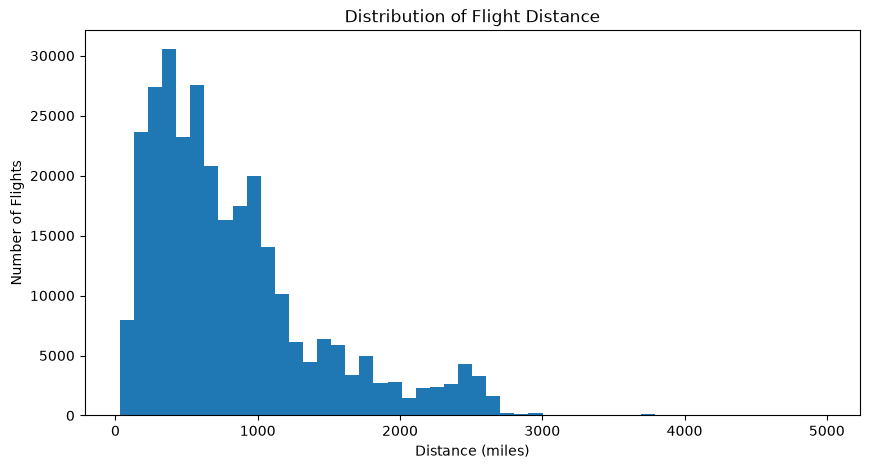

count    294678.000000
mean        823.999932
std         607.989198
min          31.000000
25%         373.000000
50%         649.000000
75%        1065.000000
max        4983.000000
Name: DISTANCE, dtype: float64

In [21]:
# ============================================================
# 17. FLIGHT DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["DISTANCE"].dropna(),
    bins=50
)

plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Flights")

plt.show()

df["DISTANCE"].describe()

# 4. Feature Engineering

Additional features are derived from the scheduled flight information to help the machine learning models capture temporal, seasonal, route, and airport-traffic patterns.

Only information available before departure is used to avoid data leakage.

In [22]:
# ============================================================
# 18. DEPARTURE TIME FEATURES
# ============================================================

df["Departure_Hour"] = (
    df["SCHEDULED_DEPARTURE"] // 100
).astype(int).clip(0, 23)

df["Departure_Minute"] = (
    df["SCHEDULED_DEPARTURE"] % 100
).astype(int)

print(
    df[
        ["SCHEDULED_DEPARTURE",
         "Departure_Hour",
         "Departure_Minute"]
    ].head()
)

   SCHEDULED_DEPARTURE  Departure_Hour  Departure_Minute
0                 1340              13                40
1                 1910              19                10
2                  630               6                30
3                  810               8                10
4                 1000              10                 0


In [23]:
# ============================================================
# 19. PEAK HOUR AND WEEKEND FEATURES
# ============================================================

df["Peak_Hour"] = (
    df["Departure_Hour"].isin(
        [6, 7, 8, 9, 16, 17, 18, 19]
    )
).astype(int)

df["Weekend"] = (
    df["DAY_OF_WEEK"].isin([6, 7])
).astype(int)

print(df[[
    "Departure_Hour",
    "Peak_Hour",
    "DAY_OF_WEEK",
    "Weekend"
]].head())

   Departure_Hour  Peak_Hour  DAY_OF_WEEK  Weekend
0              13          0            2        0
1              19          1            6        1
2               6          1            3        0
3               8          1            2        0
4              10          0            1        0


In [24]:
# ============================================================
# 20. TIME OF DAY
# ============================================================

def get_time_of_day(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


df["Time_of_Day"] = (
    df["Departure_Hour"]
    .apply(get_time_of_day)
)

df["Time_of_Day"].value_counts()

Time_of_Day
Morning      120636
Afternoon     89062
Evening       66313
Night         18667
Name: count, dtype: int64

In [25]:
# ============================================================
# 21. SEASONAL FEATURES
# ============================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["MONTH"].apply(get_season)

df["Quarter"] = (
    ((df["MONTH"] - 1) // 3) + 1
).astype(int)

print(df[[
    "MONTH",
    "Season",
    "Quarter"
]].head())

   MONTH  Season  Quarter
0      4  Spring        2
1      1  Winter        1
2      7  Summer        3
3      5  Spring        2
4      7  Summer        3


In [26]:
# ============================================================
# 22. DISTANCE CATEGORY
# ============================================================

df["Distance_Category"] = pd.cut(
    df["DISTANCE"],
    bins=[
        -np.inf,
        500,
        1000,
        2000,
        np.inf
    ],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

df["Distance_Category"].value_counts()

Distance_Category
Short        107586
Medium       103242
Long          64808
Very Long     19042
Name: count, dtype: int64

In [27]:
# ============================================================
# 23. ROUTE FEATURE
# ============================================================

df["Route"] = (
    df["ORIGIN_AIRPORT"].astype(str)
    + "_"
    + df["DESTINATION_AIRPORT"].astype(str)
)

print("Unique Routes:", df["Route"].nunique())

df["Route"].head()

Unique Routes: 7998


0    FWA_DTW
1    LAS_SEA
2    OAK_SEA
3    STL_DAL
4    IAH_HNL
Name: Route, dtype: str

In [28]:
# ============================================================
# 24. AIRPORT AND ROUTE TRAFFIC
# ============================================================

origin_traffic = df[
    "ORIGIN_AIRPORT"
].value_counts()

destination_traffic = df[
    "DESTINATION_AIRPORT"
].value_counts()

route_frequency = df[
    "Route"
].value_counts()


df["Origin_Traffic"] = (
    df["ORIGIN_AIRPORT"]
    .map(origin_traffic)
)

df["Destination_Traffic"] = (
    df["DESTINATION_AIRPORT"]
    .map(destination_traffic)
)

df["Route_Frequency"] = (
    df["Route"]
    .map(route_frequency)
)

df[[
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "Origin_Traffic",
    "Destination_Traffic",
    "Route_Frequency"
]].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,Origin_Traffic,Destination_Traffic,Route_Frequency
0,FWA,DTW,271,5617,52
1,LAS,SEA,6799,5590,226
2,OAK,SEA,2177,5590,165
3,STL,DAL,2348,3069,93
4,IAH,HNL,7401,2234,14


In [29]:
# ============================================================
# 25. VERIFY ENGINEERED FEATURES
# ============================================================

engineered_features = [
    "Departure_Hour",
    "Departure_Minute",
    "Peak_Hour",
    "Weekend",
    "Time_of_Day",
    "Season",
    "Quarter",
    "Distance_Category",
    "Route",
    "Origin_Traffic",
    "Destination_Traffic",
    "Route_Frequency"
]

missing_features = [
    col
    for col in engineered_features
    if col not in df.columns
]

print("Dataset Shape:", df.shape)

print("\nEngineered Features:")
for feature in engineered_features:
    print("✓", feature)

print("\nMissing Features:", missing_features)

Dataset Shape: (294678, 26)

Engineered Features:
✓ Departure_Hour
✓ Departure_Minute
✓ Peak_Hour
✓ Weekend
✓ Time_of_Day
✓ Season
✓ Quarter
✓ Distance_Category
✓ Route
✓ Origin_Traffic
✓ Destination_Traffic
✓ Route_Frequency

Missing Features: []


# 5. Weather Data Integration

Historical weather information is integrated with the flight dataset using the origin airport's city and the scheduled flight date and hour.

The following weather variables are considered:

- Temperature
- Humidity
- Atmospheric Pressure
- Wind Speed
- Weather Description

Weather conditions at the origin airport are used because they can influence departure operations and consequently contribute to flight delays.

In [30]:
# ============================================================
# 26. AIRPORT → CITY MAPPING
# ============================================================

airport_city = (
    airports[
        ["IATA_CODE", "CITY"]
    ]
    .dropna()
    .drop_duplicates("IATA_CODE")
    .copy()
)

airport_city["IATA_CODE"] = (
    airport_city["IATA_CODE"]
    .astype(str)
    .str.strip()
)

airport_city["CITY"] = (
    airport_city["CITY"]
    .astype(str)
    .str.strip()
)

print("Airport-city mappings:", len(airport_city))

airport_city.head()

Airport-city mappings: 322


,IATA_CODE,CITY
0,ABE,Allentown
1,ABI,Abilene
2,ABQ,Albuquerque
3,ABR,Aberdeen
4,ABY,Albany


In [31]:
# ============================================================
# 27. ADD ORIGIN CITY
# ============================================================

df["ORIGIN_AIRPORT"] = (
    df["ORIGIN_AIRPORT"]
    .astype(str)
    .str.strip()
)

city_map = dict(
    zip(
        airport_city["IATA_CODE"],
        airport_city["CITY"]
    )
)

df["Origin_City"] = (
    df["ORIGIN_AIRPORT"]
    .map(city_map)
)

print("Flights:", len(df))

print(
    "Flights with origin city:",
    df["Origin_City"].notna().sum()
)

print(
    "Missing origin city:",
    df["Origin_City"].isna().sum()
)

df[
    ["ORIGIN_AIRPORT", "Origin_City"]
].head()

Flights: 294678
Flights with origin city: 269770
Missing origin city: 24908


,ORIGIN_AIRPORT,Origin_City
0,FWA,Fort Wayne
1,LAS,Las Vegas
2,OAK,Oakland
3,STL,St Louis
4,IAH,Houston


In [32]:
# ============================================================
# 28. CREATE FLIGHT DATETIME
# ============================================================

df["Flight_Date"] = pd.to_datetime(
    dict(
        year=df["YEAR"],
        month=df["MONTH"],
        day=df["DAY"]
    ),
    errors="coerce"
)

df["Flight_Datetime"] = (
    df["Flight_Date"]
    + pd.to_timedelta(
        df["Departure_Hour"],
        unit="h"
    )
)

print(
    df[
        [
            "YEAR",
            "MONTH",
            "DAY",
            "Departure_Hour",
            "Flight_Datetime"
        ]
    ].head()
)

   YEAR  MONTH  DAY  Departure_Hour     Flight_Datetime
0  2015      4    7              13 2015-04-07 13:00:00
1  2015      1   24              19 2015-01-24 19:00:00
2  2015      7    8               6 2015-07-08 06:00:00
3  2015      5   26               8 2015-05-26 08:00:00
4  2015      7    6              10 2015-07-06 10:00:00


In [33]:
# ============================================================
# 29. WEATHER RESHAPING FUNCTION
# ============================================================

def reshape_weather(data, value_name):

    temp = data.copy()

    temp["datetime"] = pd.to_datetime(
        temp["datetime"],
        errors="coerce"
    )

    temp = temp.melt(
        id_vars="datetime",
        var_name="City",
        value_name=value_name
    )

    temp["City"] = (
        temp["City"]
        .astype(str)
        .str.strip()
    )

    return temp

In [34]:
temperature_long = reshape_weather(
    temperature,
    "Temperature"
)

humidity_long = reshape_weather(
    humidity,
    "Humidity"
)

pressure_long = reshape_weather(
    pressure,
    "Pressure"
)

wind_long = reshape_weather(
    wind_speed,
    "Wind_Speed"
)

description_long = reshape_weather(
    weather_description,
    "Weather_Description"
)

print("Temperature:", temperature_long.shape)
print("Humidity:", humidity_long.shape)
print("Pressure:", pressure_long.shape)
print("Wind:", wind_long.shape)
print("Description:", description_long.shape)

Temperature: (1629108, 3)
Humidity: (1629108, 3)
Pressure: (1629108, 3)
Wind: (1629108, 3)
Description: (1629108, 3)


In [35]:
# ============================================================
# 30. COMBINE WEATHER DATA
# ============================================================

weather = temperature_long.merge(
    humidity_long,
    on=["datetime", "City"],
    how="outer"
)

weather = weather.merge(
    pressure_long,
    on=["datetime", "City"],
    how="outer"
)

weather = weather.merge(
    wind_long,
    on=["datetime", "City"],
    how="outer"
)

weather = weather.merge(
    description_long,
    on=["datetime", "City"],
    how="outer"
)

print("Combined weather shape:")
print(weather.shape)

weather.head()

Combined weather shape:
(1629108, 7)


,datetime,City,Temperature,Humidity,Pressure,Wind_Speed,Weather_Description
0,2012-10-01 12:00:00,Albuquerque,NaN,NaN,NaN,NaN,NaN
1,2012-10-01 12:00:00,Atlanta,NaN,NaN,NaN,NaN,NaN
2,2012-10-01 12:00:00,Beersheba,NaN,NaN,NaN,NaN,NaN
3,2012-10-01 12:00:00,Boston,NaN,NaN,NaN,NaN,NaN
4,2012-10-01 12:00:00,Charlotte,NaN,NaN,NaN,NaN,NaN


In [36]:
# ============================================================
# 31. CHECK CITY MATCHING
# ============================================================

flight_cities = set(
    df["Origin_City"]
    .dropna()
    .unique()
)

weather_cities = set(
    weather["City"]
    .dropna()
    .unique()
)

matched_cities = (
    flight_cities &
    weather_cities
)

print("Flight Origin Cities:", len(flight_cities))
print("Weather Cities:", len(weather_cities))
print("Matched Cities:", len(matched_cities))

print("\nMatched Cities:")
print(sorted(matched_cities))

Flight Origin Cities: 306
Weather Cities: 36
Matched Cities: 26

Matched Cities:
['Albuquerque', 'Atlanta', 'Boston', 'Charlotte', 'Chicago', 'Dallas', 'Denver', 'Detroit', 'Houston', 'Indianapolis', 'Jacksonville', 'Kansas City', 'Las Vegas', 'Los Angeles', 'Miami', 'Minneapolis', 'Nashville', 'New York', 'Philadelphia', 'Phoenix', 'Pittsburgh', 'Portland', 'San Antonio', 'San Diego', 'San Francisco', 'Seattle']


In [37]:
# ============================================================
# 32. MERGE FLIGHTS WITH WEATHER
# ============================================================

before_merge = len(df)

df = df.merge(
    weather,
    left_on=[
        "Flight_Datetime",
        "Origin_City"
    ],
    right_on=[
        "datetime",
        "City"
    ],
    how="left"
)

after_merge = len(df)

print("Rows before merge:", before_merge)
print("Rows after merge :", after_merge)

print("\nWeather availability:")

weather_columns = [
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Weather_Description"
]

for col in weather_columns:

    available = (
        df[col].notna().mean() * 100
    )

    print(
        f"{col:20s}: {available:.2f}%"
    )

Rows before merge: 294678
Rows after merge : 294678

Weather availability:
Temperature         : 51.22%
Humidity            : 51.21%
Pressure            : 51.22%
Wind_Speed          : 51.22%
Weather_Description : 51.22%


In [38]:
# ============================================================
# 33. CLEAN MERGE COLUMNS
# ============================================================

df.drop(
    columns=[
        "datetime",
        "City"
    ],
    inplace=True,
    errors="ignore"
)

print("Dataset Shape:", df.shape)

print("\nWeather columns added:")

for col in weather_columns:
    print(
        col,
        "→",
        col in df.columns
    )

Dataset Shape: (294678, 34)

Weather columns added:
Temperature → True
Humidity → True
Pressure → True
Wind_Speed → True
Weather_Description → True


# 6. Final Data Preparation and Train-Test Split

The dataset contains missing weather information for airports whose cities are not covered by the historical weather dataset.

Rather than removing these flights, missing numerical weather values are handled during preprocessing using median imputation. A separate indicator is retained to tell the model whether actual weather data was available.

The data is then split into training and testing sets before creating any target-based historical features. This prevents data leakage.

In [39]:
# ============================================================
# 34. WEATHER AVAILABILITY FEATURE
# ============================================================

df["Weather_Available"] = (
    df["Temperature"].notna()
).astype(int)

print(
    df["Weather_Available"]
    .value_counts()
)

print("\nPercentages:")

print(
    (
        df["Weather_Available"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Weather_Available
1    150925
0    143753
Name: count, dtype: int64

Percentages:
Weather_Available
1    51.22
0    48.78
Name: proportion, dtype: float64


In [40]:
# ============================================================
# 35. WEATHER DESCRIPTION CLEANING
# ============================================================

df["Weather_Description"] = (
    df["Weather_Description"]
    .fillna("Unknown")
    .astype(str)
)

print(
    df["Weather_Description"]
    .value_counts()
    .head(15)
)

Weather_Description
Unknown                    143753
sky is clear                56534
light rain                  15223
broken clouds               14841
scattered clouds            13635
few clouds                  11503
mist                        10417
overcast clouds              8591
moderate rain                7020
heavy intensity rain         2784
haze                         2678
light snow                   2299
fog                          1503
snow                         1103
light intensity drizzle       771
Name: count, dtype: int64


In [41]:
# ============================================================
# 36. REMOVE HELPER COLUMNS
# ============================================================

df.drop(
    columns=[
        "Flight_Date",
        "Flight_Datetime",
        "Origin_City"
    ],
    inplace=True,
    errors="ignore"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (294678, 32)

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DELAYED', 'Departure_Hour', 'Departure_Minute', 'Peak_Hour', 'Weekend', 'Time_of_Day', 'Season', 'Quarter', 'Distance_Category', 'Route', 'Origin_Traffic', 'Destination_Traffic', 'Route_Frequency', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'Weather_Description', 'Weather_Available']


In [42]:
# ============================================================
# 37. BASE MODEL FEATURES
# ============================================================

base_features = [
    # Calendar
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "Quarter",
    "Weekend",

    # Airline / airports
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",

    # Flight characteristics
    "DISTANCE",
    "Departure_Hour",
    "Departure_Minute",
    "Peak_Hour",
    "Time_of_Day",
    "Season",
    "Distance_Category",

    # Traffic
    "Origin_Traffic",
    "Destination_Traffic",
    "Route_Frequency",

    # Weather
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Weather_Description",
    "Weather_Available"
]

target = "DELAYED"

X = df[base_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of base features:", len(base_features))

X shape: (294678, 24)
y shape: (294678,)
Number of base features: 24


In [43]:
# ============================================================
# 38. TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(
    (
        y_train.value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\nTesting target distribution:")
print(
    (
        y_test.value_counts(normalize=True)
        * 100
    ).round(2)
)

Training set: (235742, 24)
Testing set : (58936, 24)

Training target distribution:
DELAYED
0    81.35
1    18.65
Name: proportion, dtype: float64

Testing target distribution:
DELAYED
0    81.35
1    18.65
Name: proportion, dtype: float64


In [44]:
# ============================================================
# 39. LEAKAGE-FREE DELAY RATE FEATURES
# ============================================================

train_rates = X_train.copy()

train_rates["DELAYED"] = y_train.values

global_delay_rate = y_train.mean()

# Airline delay rate
airline_rates = (
    train_rates
    .groupby("AIRLINE")["DELAYED"]
    .mean()
)

# Origin airport delay rate
origin_rates = (
    train_rates
    .groupby("ORIGIN_AIRPORT")["DELAYED"]
    .mean()
)

# Destination airport delay rate
destination_rates = (
    train_rates
    .groupby("DESTINATION_AIRPORT")["DELAYED"]
    .mean()
)

In [45]:
X_train["Airline_Delay_Rate"] = (
    X_train["AIRLINE"]
    .map(airline_rates)
    .fillna(global_delay_rate)
)

X_test["Airline_Delay_Rate"] = (
    X_test["AIRLINE"]
    .map(airline_rates)
    .fillna(global_delay_rate)
)


X_train["Origin_Delay_Rate"] = (
    X_train["ORIGIN_AIRPORT"]
    .map(origin_rates)
    .fillna(global_delay_rate)
)

X_test["Origin_Delay_Rate"] = (
    X_test["ORIGIN_AIRPORT"]
    .map(origin_rates)
    .fillna(global_delay_rate)
)


X_train["Destination_Delay_Rate"] = (
    X_train["DESTINATION_AIRPORT"]
    .map(destination_rates)
    .fillna(global_delay_rate)
)

X_test["Destination_Delay_Rate"] = (
    X_test["DESTINATION_AIRPORT"]
    .map(destination_rates)
    .fillna(global_delay_rate)
)

In [46]:
delay_rate_features = [
    "Airline_Delay_Rate",
    "Origin_Delay_Rate",
    "Destination_Delay_Rate"
]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nDelay-rate features:")

display(
    X_train[
        delay_rate_features
    ].describe()
)

print("\nMissing values:")

print(
    X_train[
        delay_rate_features
    ].isna().sum()
)

Training: (235742, 27)
Testing : (58936, 27)

Delay-rate features:


,Airline_Delay_Rate,Origin_Delay_Rate,Destination_Delay_Rate
count,235742.000000,235742.000000,235742.000000
mean,0.186462,0.186462,0.186462
std,0.032138,0.040501,0.039244
min,0.110868,0.000000,0.000000
25%,0.186116,0.159483,0.169598
50%,0.191900,0.188251,0.188493
75%,0.195787,0.215490,0.210559
max,0.289604,1.000000,1.000000



Missing values:
Airline_Delay_Rate        0
Origin_Delay_Rate         0
Destination_Delay_Rate    0
dtype: int64


# 7. Data Preprocessing and Baseline Model

Numerical and categorical variables require different preprocessing steps.

- Missing numerical values are replaced using the median calculated from the training data.
- Missing categorical values are replaced using the most frequent category.
- Categorical variables are transformed using One-Hot Encoding.
- Numerical variables are standardized for models that are sensitive to feature scale.

A Logistic Regression model with balanced class weights is first trained as a baseline.

In [47]:
# ============================================================
# 40. DEFINE FEATURE TYPES
# ============================================================

numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "Quarter",
    "Weekend",
    "DISTANCE",
    "Departure_Hour",
    "Departure_Minute",
    "Peak_Hour",
    "Origin_Traffic",
    "Destination_Traffic",
    "Route_Frequency",
    "Temperature",
    "Humidity",
    "Pressure",
    "Wind_Speed",
    "Weather_Available",

    # Leakage-free historical features
    "Airline_Delay_Rate",
    "Origin_Delay_Rate",
    "Destination_Delay_Rate"
]

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "Time_of_Day",
    "Season",
    "Distance_Category",
    "Weather_Description"
]

print("Numerical features  :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features      :", len(numeric_features) + len(categorical_features))

Numerical features  : 20
Categorical features: 7
Total features      : 27


In [48]:
# ============================================================
# 41. PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [50]:
# ============================================================
# FIX MIXED CATEGORICAL DATA TYPES
# ============================================================

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "Time_of_Day",
    "Season",
    "Distance_Category",
    "Weather_Description"
]

for col in categorical_features:
    X_train[col] = X_train[col].astype("string").fillna("Unknown")
    X_test[col] = X_test[col].astype("string").fillna("Unknown")

print("Categorical columns converted successfully!")

for col in categorical_features:
    print(
        col,
        "→",
        X_train[col].dropna().map(type).value_counts().to_dict()
    )

Categorical columns converted successfully!
AIRLINE → {<class 'str'>: 235742}
ORIGIN_AIRPORT → {<class 'str'>: 235742}
DESTINATION_AIRPORT → {<class 'str'>: 235742}
Time_of_Day → {<class 'str'>: 235742}
Season → {<class 'str'>: 235742}
Distance_Category → {<class 'str'>: 235742}
Weather_Description → {<class 'str'>: 235742}


In [51]:
# ============================================================
# 42. LOGISTIC REGRESSION BASELINE
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

print("Training Logistic Regression...")

lr_pipeline.fit(
    X_train,
    y_train
)

print("Training complete!")

Training Logistic Regression...
Training complete!


In [52]:
# ============================================================
# 43. BASELINE PREDICTIONS
# ============================================================

lr_pred = lr_pipeline.predict(X_test)

lr_prob = lr_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [53]:
# ============================================================
# 44. BASELINE EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

lr_pr_auc = average_precision_score(
    y_test,
    lr_prob
)


print("LOGISTIC REGRESSION — CLEAN BASELINE")
print("=" * 45)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_auc:.4f}")
print(f"PR-AUC    : {lr_pr_auc:.4f}")

LOGISTIC REGRESSION — CLEAN BASELINE
Accuracy  : 0.6088
Precision : 0.2660
Recall    : 0.6239
F1 Score  : 0.3729
ROC-AUC   : 0.6549
PR-AUC    : 0.2935


In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "On Time",
            "Delayed"
        ]
    )
)

              precision    recall  f1-score   support

     On Time       0.88      0.61      0.72     47947
     Delayed       0.27      0.62      0.37     10989

    accuracy                           0.61     58936
   macro avg       0.57      0.61      0.54     58936
weighted avg       0.76      0.61      0.65     58936



In [55]:
# ============================================================
# 45. XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [56]:
# Calculate class weight from TRAINING DATA only

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("On-time flights :", negative)
print("Delayed flights :", positive)
print("Scale Pos Weight:", round(scale_pos_weight, 3))

On-time flights : 191785
Delayed flights : 43957
Scale Pos Weight: 4.363


In [57]:
# ============================================================
# 46. TREE PREPROCESSOR
# ============================================================

tree_numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

tree_categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

tree_preprocessor = ColumnTransformer([
    (
        "num",
        tree_numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        tree_categorical_transformer,
        categorical_features
    )
])

print("Tree preprocessor created!")

Tree preprocessor created!


In [58]:
# ============================================================
# 47. TRAIN XGBOOST
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,

    reg_alpha=0.1,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    (
        "preprocessor",
        tree_preprocessor
    ),
    (
        "classifier",
        xgb_model
    )
])

print("Training XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training complete!")

Training XGBoost...
XGBoost training complete!


In [59]:
# ============================================================
# 48. XGBOOST EVALUATION
# ============================================================

xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:, 1]


xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)


print("XGBOOST")
print("=" * 45)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")

XGBOOST
Accuracy  : 0.6541
Precision : 0.2990
Recall    : 0.6362
F1 Score  : 0.4068
ROC-AUC   : 0.7017
PR-AUC    : 0.3620


In [60]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        xgb_recall
    ],

    "F1 Score": [
        lr_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_auc,
        xgb_auc
    ],

    "PR-AUC": [
        lr_pr_auc,
        xgb_pr_auc
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6088,0.266,0.6239,0.3729,0.6549,0.2935
1,XGBoost,0.6541,0.299,0.6362,0.4068,0.7017,0.3620


# 8. Classification Threshold Optimization

The default classification threshold of 0.50 does not necessarily provide the best balance between precision and recall.

Different probability thresholds are evaluated using the validation predictions to identify a threshold that maximizes the F1-score while maintaining useful recall for delayed flights.

In [62]:
# ============================================================
# 49. THRESHOLD ANALYSIS
# ============================================================

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.02):

    pred_threshold = (
        xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred_threshold
        ),
        "F1": f1_score(
            y_test,
            pred_threshold
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.2378,0.1944,0.9821,0.3245
1,0.22,0.2561,0.1975,0.9757,0.3285
2,0.24,0.2766,0.2011,0.9687,0.3330
3,0.26,0.2992,0.2050,0.9581,0.3377
4,0.28,0.3241,0.2091,0.9432,0.3423
5,0.30,0.3531,0.2146,0.9284,0.3486
6,0.32,0.3836,0.2208,0.9115,0.3554
7,0.34,0.4155,0.2274,0.8903,0.3623
8,0.36,0.4460,0.2342,0.8682,0.3689
9,0.38,0.4753,0.2407,0.8422,0.3744


In [63]:
# ============================================================
# 50. BEST THRESHOLD
# ============================================================

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best threshold:", round(best_threshold, 2))

print("\nPerformance at best threshold:")
print(best_row.round(4))

Best threshold: 0.54

Performance at best threshold:
Threshold    0.5400
Accuracy     0.7052
Precision    0.3266
Recall       0.5472
F1           0.4090
Name: 17, dtype: float64


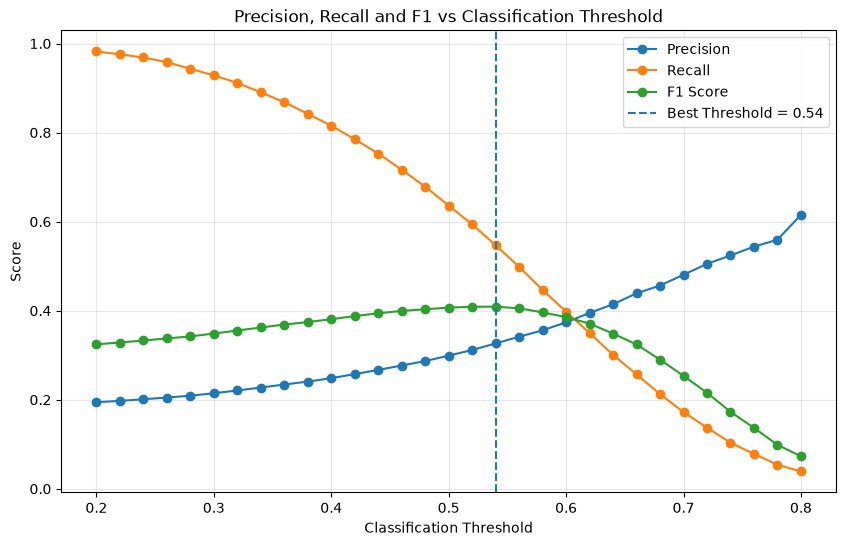

In [64]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Classification Threshold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [65]:
# ============================================================
# 51. OPTIMIZED XGBOOST PERFORMANCE
# ============================================================

xgb_pred_opt = (
    xgb_prob >= best_threshold
).astype(int)

opt_accuracy = accuracy_score(
    y_test,
    xgb_pred_opt
)

opt_precision = precision_score(
    y_test,
    xgb_pred_opt
)

opt_recall = recall_score(
    y_test,
    xgb_pred_opt
)

opt_f1 = f1_score(
    y_test,
    xgb_pred_opt
)


print("XGBOOST — OPTIMIZED THRESHOLD")
print("=" * 45)

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {opt_accuracy:.4f}")
print(f"Precision : {opt_precision:.4f}")
print(f"Recall    : {opt_recall:.4f}")
print(f"F1 Score  : {opt_f1:.4f}")
print(f"ROC-AUC   : {xgb_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")

XGBOOST — OPTIMIZED THRESHOLD
Threshold : 0.54
Accuracy  : 0.7052
Precision : 0.3266
Recall    : 0.5472
F1 Score  : 0.4090
ROC-AUC   : 0.7017
PR-AUC    : 0.3620


# 9. XGBoost Hyperparameter Tuning

The baseline XGBoost model outperformed Logistic Regression across all major evaluation metrics.

To further improve predictive performance, selected XGBoost hyperparameters are tuned using cross-validation. Since the dataset is imbalanced, F1-score is used as the primary optimization metric rather than accuracy alone.

In [66]:
# ============================================================
# 52. RANDOMIZED HYPERPARAMETER SEARCH
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "classifier__n_estimators": [
        300, 500, 700
    ],

    "classifier__max_depth": [
        4, 6, 8, 10
    ],

    "classifier__learning_rate": [
        0.03, 0.05, 0.08, 0.1
    ],

    "classifier__subsample": [
        0.7, 0.8, 0.9
    ],

    "classifier__colsample_bytree": [
        0.7, 0.8, 0.9
    ],

    "classifier__min_child_weight": [
        1, 3, 5, 7
    ],

    "classifier__gamma": [
        0, 0.1, 0.3
    ]
}


random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,

    n_iter=12,

    scoring="f1",

    cv=3,

    verbose=2,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

print("Starting XGBoost tuning...")

random_search.fit(
    X_train,
    y_train
)

print("\nTuning complete!")

Starting XGBoost tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Tuning complete!


In [67]:
print("Best Parameters:")
print(random_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(random_search.best_score_, 4)
)

Best Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 5, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.03, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.7}

Best Cross-Validation F1: 0.4171


In [68]:
# ============================================================
# 53. EVALUATE TUNED XGBOOST
# ============================================================

best_xgb = random_search.best_estimator_

tuned_prob = best_xgb.predict_proba(
    X_test
)[:, 1]

tuned_pred = best_xgb.predict(
    X_test
)


tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_prob
)

tuned_pr_auc = average_precision_score(
    y_test,
    tuned_prob
)


print("TUNED XGBOOST")
print("=" * 45)

print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")
print(f"ROC-AUC   : {tuned_auc:.4f}")
print(f"PR-AUC    : {tuned_pr_auc:.4f}")

TUNED XGBOOST
Accuracy  : 0.6942
Precision : 0.3245
Recall    : 0.5914
F1 Score  : 0.4190
ROC-AUC   : 0.7124
PR-AUC    : 0.3835


# 10. Advanced Feature Engineering

Additional interaction and weather-severity features are created to capture more complex relationships associated with flight delays.

These features use only information that is available before the scheduled departure of the flight, preventing target leakage.

In [69]:
# ============================================================
# 54. TRAFFIC INTERACTION FEATURES
# ============================================================

for data in [X_train, X_test]:

    data["Peak_Origin_Traffic"] = (
        data["Peak_Hour"] *
        data["Origin_Traffic"]
    )

    data["Peak_Destination_Traffic"] = (
        data["Peak_Hour"] *
        data["Destination_Traffic"]
    )

print("Traffic interaction features created.")

Traffic interaction features created.


In [70]:
# ============================================================
# 55. DISTANCE / TRAFFIC INTERACTIONS
# ============================================================

for data in [X_train, X_test]:

    data["Distance_Origin_Traffic"] = (
        data["DISTANCE"] *
        data["Origin_Traffic"]
    )

    data["Distance_Destination_Traffic"] = (
        data["DISTANCE"] *
        data["Destination_Traffic"]
    )

print("Distance interaction features created.")

Distance interaction features created.


In [71]:
# ============================================================
# 56. WEATHER SEVERITY FEATURES
# ============================================================

for data in [X_train, X_test]:

    data["High_Wind"] = (
        data["Wind_Speed"] >= 10
    ).astype(int)

    data["Low_Visibility_Weather"] = (
        data["Weather_Description"]
        .astype(str)
        .str.lower()
        .str.contains(
            "fog|mist|haze",
            regex=True,
            na=False
        )
    ).astype(int)

    data["Storm_Weather"] = (
        data["Weather_Description"]
        .astype(str)
        .str.lower()
        .str.contains(
            "storm|thunder|squall",
            regex=True,
            na=False
        )
    ).astype(int)

    data["Rain_Snow"] = (
        data["Weather_Description"]
        .astype(str)
        .str.lower()
        .str.contains(
            "rain|snow|drizzle",
            regex=True,
            na=False
        )
    ).astype(int)

print("Weather severity features created.")

Weather severity features created.


In [72]:
# ============================================================
# 57. TEMPERATURE FEATURES
# ============================================================

for data in [X_train, X_test]:

    data["Temperature_C"] = (
        data["Temperature"] - 273.15
    )

    data["Freezing"] = (
        data["Temperature_C"] <= 0
    ).astype(int)

    data["Very_Hot"] = (
        data["Temperature_C"] >= 35
    ).astype(int)

print("Temperature features created.")

Temperature features created.


In [73]:
# ============================================================
# 58. SCHEDULE INTERACTIONS
# ============================================================

for data in [X_train, X_test]:

    # Later flights may accumulate operational disruption
    data["Hour_Squared"] = (
        data["Departure_Hour"] ** 2
    )

    # Weekend + peak interaction
    data["Weekend_Peak"] = (
        data["Weekend"] *
        data["Peak_Hour"]
    )

print("Schedule interaction features created.")

Schedule interaction features created.


In [74]:
advanced_numeric_features = [
    "Peak_Origin_Traffic",
    "Peak_Destination_Traffic",
    "Distance_Origin_Traffic",
    "Distance_Destination_Traffic",

    "High_Wind",
    "Low_Visibility_Weather",
    "Storm_Weather",
    "Rain_Snow",

    "Temperature_C",
    "Freezing",
    "Very_Hot",

    "Hour_Squared",
    "Weekend_Peak"
]

numeric_features = (
    numeric_features +
    advanced_numeric_features
)

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Total:",
    len(numeric_features)
    + len(categorical_features)
)

Numerical features: 33
Categorical features: 7
Total: 40


In [75]:
# ============================================================
# 59. VERIFY ADVANCED FEATURES
# ============================================================

missing_train = [
    col for col in advanced_numeric_features
    if col not in X_train.columns
]

missing_test = [
    col for col in advanced_numeric_features
    if col not in X_test.columns
]

print("Missing from training:", missing_train)
print("Missing from testing :", missing_test)

print("\nTraining shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nAdvanced feature sample:")

display(
    X_train[
        advanced_numeric_features
    ].head()
)

Missing from training: []
Missing from testing : []

Training shape: (235742, 40)
Testing shape : (58936, 40)

Advanced feature sample:


,Peak_Origin_Traffic,Peak_Destination_Traffic,Distance_Origin_Traffic,Distance_Destination_Traffic,High_Wind,Low_Visibility_Weather,Storm_Weather,Rain_Snow,Temperature_C,Freezing,Very_Hot,Hour_Squared,Weekend_Peak
32824,1984,14177,799552,5713331,0,0,0,0,34.700000,0,0,361,0
294629,3333,1234,893244,330712,0,0,0,1,26.920000,0,0,256,0
18476,9880,548,25836200,1433020,0,0,0,0,18.090000,0,0,49,0
66522,0,0,1659728,15776,0,0,0,0,13.023667,0,0,100,0
175635,5606,3744,6317962,4219488,0,0,0,0,-7.992333,1,0,289,0


# 11. Advanced XGBoost Model

The tuned XGBoost configuration is retrained using the expanded feature set.

The advanced feature set includes traffic interactions, weather severity indicators, temperature-based features, and schedule interactions. Performance is compared with the previous tuned XGBoost model to determine whether the additional features provide meaningful predictive improvement.

In [76]:
# ============================================================
# 60. ADVANCED TREE PREPROCESSOR
# ============================================================

advanced_tree_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]),
        numeric_features
    ),

    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        categorical_features
    )
])

print("Advanced preprocessor created successfully!")

Advanced preprocessor created successfully!


In [77]:
# ============================================================
# 61. ADVANCED XGBOOST
# ============================================================

advanced_xgb_model = XGBClassifier(

    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,

    subsample=0.8,
    colsample_bytree=0.7,

    min_child_weight=5,
    gamma=0,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=RANDOM_STATE,
    n_jobs=-1
)


advanced_xgb_pipeline = Pipeline([
    (
        "preprocessor",
        advanced_tree_preprocessor
    ),
    (
        "classifier",
        advanced_xgb_model
    )
])

print("Advanced XGBoost pipeline created!")

Advanced XGBoost pipeline created!


In [78]:
# ============================================================
# 62. TRAIN ADVANCED MODEL
# ============================================================

print("Training Advanced XGBoost...")

advanced_xgb_pipeline.fit(
    X_train,
    y_train
)

print("Training complete!")

Training Advanced XGBoost...
Training complete!


In [79]:
# ============================================================
# 63. ADVANCED MODEL PREDICTIONS
# ============================================================

advanced_pred = (
    advanced_xgb_pipeline.predict(
        X_test
    )
)

advanced_prob = (
    advanced_xgb_pipeline.predict_proba(
        X_test
    )[:, 1]
)

print("Predictions complete!")

Predictions complete!


In [80]:
# ============================================================
# 64. ADVANCED MODEL EVALUATION
# ============================================================

advanced_accuracy = accuracy_score(
    y_test,
    advanced_pred
)

advanced_precision = precision_score(
    y_test,
    advanced_pred
)

advanced_recall = recall_score(
    y_test,
    advanced_pred
)

advanced_f1 = f1_score(
    y_test,
    advanced_pred
)

advanced_auc = roc_auc_score(
    y_test,
    advanced_prob
)

advanced_pr_auc = average_precision_score(
    y_test,
    advanced_prob
)


print("ADVANCED XGBOOST")
print("=" * 45)

print(f"Accuracy  : {advanced_accuracy:.4f}")
print(f"Precision : {advanced_precision:.4f}")
print(f"Recall    : {advanced_recall:.4f}")
print(f"F1 Score  : {advanced_f1:.4f}")
print(f"ROC-AUC   : {advanced_auc:.4f}")
print(f"PR-AUC    : {advanced_pr_auc:.4f}")

ADVANCED XGBOOST
Accuracy  : 0.6967
Precision : 0.3266
Recall    : 0.5905
F1 Score  : 0.4206
ROC-AUC   : 0.7118
PR-AUC    : 0.3805


In [81]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Base XGBoost",
        "Tuned XGBoost",
        "Advanced XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        xgb_accuracy,
        tuned_accuracy,
        advanced_accuracy
    ],

    "Precision": [
        lr_precision,
        xgb_precision,
        tuned_precision,
        advanced_precision
    ],

    "Recall": [
        lr_recall,
        xgb_recall,
        tuned_recall,
        advanced_recall
    ],

    "F1 Score": [
        lr_f1,
        xgb_f1,
        tuned_f1,
        advanced_f1
    ],

    "ROC-AUC": [
        lr_auc,
        xgb_auc,
        tuned_auc,
        advanced_auc
    ],

    "PR-AUC": [
        lr_pr_auc,
        xgb_pr_auc,
        tuned_pr_auc,
        advanced_pr_auc
    ]

})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6088,0.2660,0.6239,0.3729,0.6549,0.2935
1,Base XGBoost,0.6541,0.2990,0.6362,0.4068,0.7017,0.3620
2,Tuned XGBoost,0.6942,0.3245,0.5914,0.4190,0.7124,0.3835
3,Advanced XGBoost,0.6967,0.3266,0.5905,0.4206,0.7118,0.3805


# 12. Final Model Evaluation

The Advanced XGBoost model is evaluated using multiple classification metrics and visual diagnostic tools.

Since flight delays form an imbalanced classification problem, accuracy alone is insufficient. Therefore, the evaluation includes the confusion matrix, ROC curve, Precision-Recall curve, classification report, and feature importance.

<Figure size 700x600 with 0 Axes>

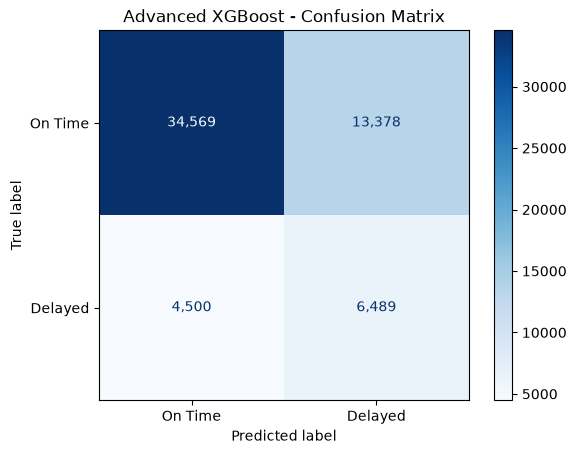

In [82]:
# ============================================================
# 65. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    advanced_pred,
    display_labels=["On Time", "Delayed"],
    cmap="Blues",
    values_format=","
)

plt.title("Advanced XGBoost - Confusion Matrix")
plt.show()

In [83]:
# ============================================================
# 66. CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("ADVANCED XGBOOST — CLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        advanced_pred,
        target_names=[
            "On Time",
            "Delayed"
        ],
        digits=4
    )
)

ADVANCED XGBOOST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time     0.8848    0.7210    0.7945     47947
     Delayed     0.3266    0.5905    0.4206     10989

    accuracy                         0.6967     58936
   macro avg     0.6057    0.6557    0.6076     58936
weighted avg     0.7807    0.6967    0.7248     58936



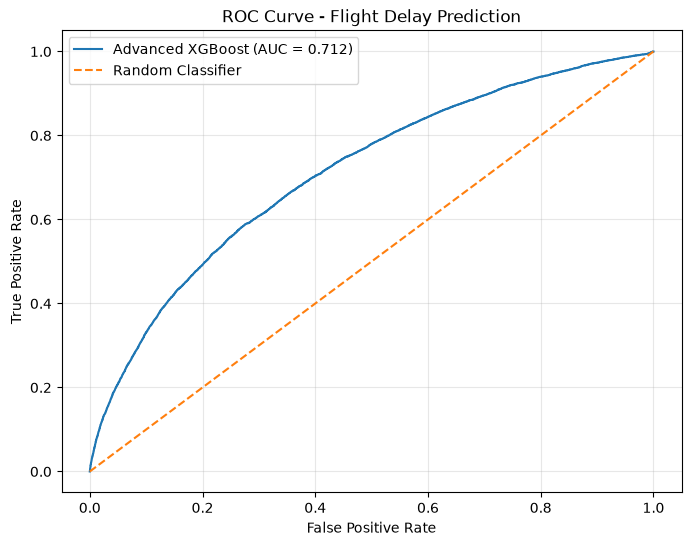

In [84]:
# ============================================================
# 67. ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    advanced_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Advanced XGBoost (AUC = {advanced_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Flight Delay Prediction")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

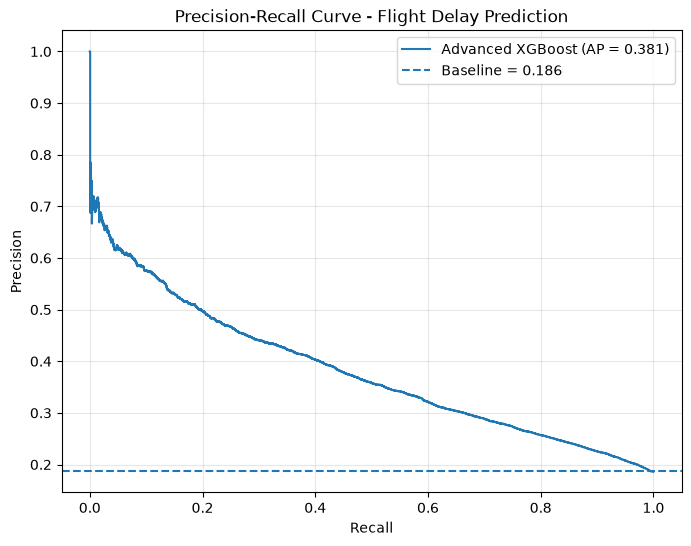

In [85]:
# ============================================================
# 68. PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        advanced_prob
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Advanced XGBoost (AP = {advanced_pr_auc:.3f})"
)

baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Flight Delay Prediction")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [86]:
# ============================================================
# 69. FEATURE IMPORTANCE
# ============================================================

final_preprocessor = (
    advanced_xgb_pipeline
    .named_steps["preprocessor"]
)

final_classifier = (
    advanced_xgb_pipeline
    .named_steps["classifier"]
)

feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

importances = (
    final_classifier
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance.head(20)
)

,Feature,Importance
0,cat__Time_of_Day_Morning,0.062384
1,num__Freezing,0.008684
2,cat__Season_Autumn,0.006169
3,num__Rain_Snow,0.004535
4,cat__Weather_Description_snow,0.003794
5,cat__ORIGIN_AIRPORT_COD,0.003611
6,cat__AIRLINE_WN,0.003519
7,num__Departure_Hour,0.003098
8,num__Storm_Weather,0.003098
9,cat__AIRLINE_NK,0.002978


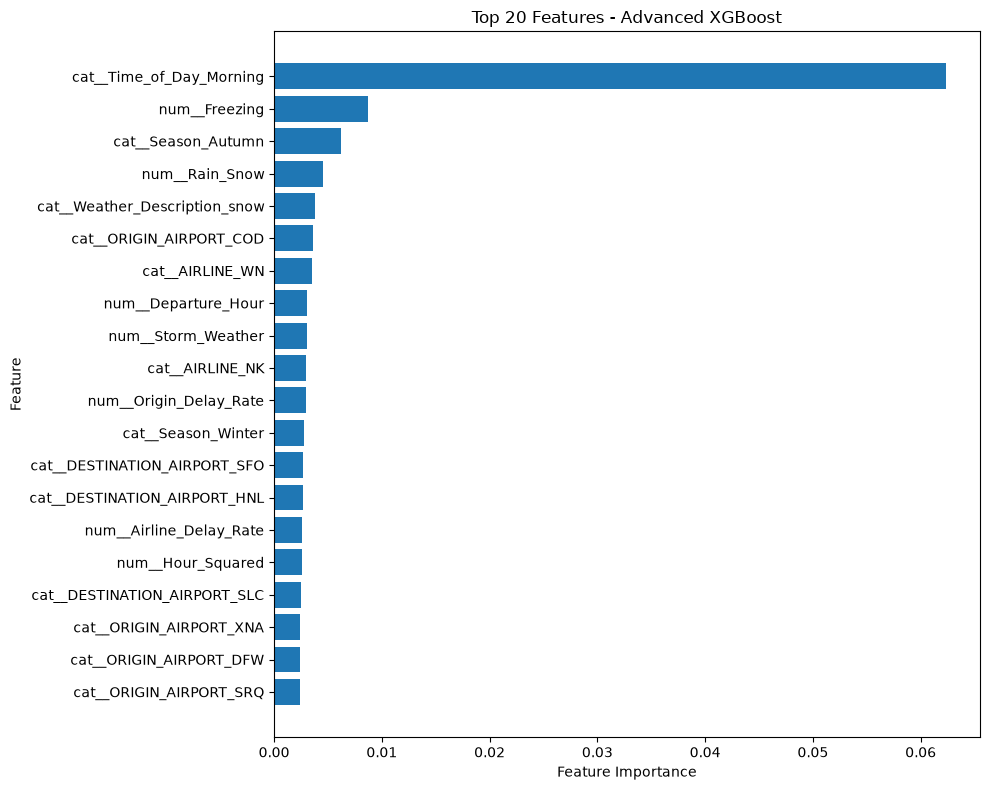

In [87]:
# ============================================================
# 70. TOP FEATURE IMPORTANCE
# ============================================================

top_features = (
    feature_importance
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Advanced XGBoost"
)

plt.tight_layout()
plt.show()

In [88]:
# ============================================================
# 71. FINAL MODEL SUMMARY
# ============================================================

final_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Score": [
        advanced_accuracy,
        advanced_precision,
        advanced_recall,
        advanced_f1,
        advanced_auc,
        advanced_pr_auc
    ]

})

final_summary["Score"] = (
    final_summary["Score"].round(4)
)

display(final_summary)

,Metric,Score
0,Accuracy,0.6967
1,Precision,0.3266
2,Recall,0.5905
3,F1 Score,0.4206
4,ROC-AUC,0.7118
5,PR-AUC,0.3805


# 13. Model Saving and Deployment Preparation

The final machine learning pipeline and supporting feature mappings are saved so that the same preprocessing and feature-engineering logic can be reproduced when predictions are generated from the Streamlit application.

In [89]:
# ============================================================
# 72. CREATE DEPLOYMENT PACKAGE
# ============================================================

import os
import pickle

os.makedirs("../models", exist_ok=True)

deployment_package = {

    # Complete preprocessing + XGBoost pipeline
    "model": advanced_xgb_pipeline,

    # Historical target-based mappings
    "airline_delay_rates": airline_rates.to_dict(),
    "origin_delay_rates": origin_rates.to_dict(),
    "destination_delay_rates": destination_rates.to_dict(),

    "global_delay_rate": float(global_delay_rate),

    # Traffic mappings
    "origin_traffic": origin_traffic.to_dict(),
    "destination_traffic": destination_traffic.to_dict(),
    "route_frequency": route_frequency.to_dict(),

    # Exact feature definitions
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,

    # Model information
    "model_name": "Advanced XGBoost",

    "metrics": {
        "accuracy": float(advanced_accuracy),
        "precision": float(advanced_precision),
        "recall": float(advanced_recall),
        "f1": float(advanced_f1),
        "roc_auc": float(advanced_auc),
        "pr_auc": float(advanced_pr_auc)
    }
}

print("Deployment package created.")

Deployment package created.


In [90]:
# ============================================================
# 73. SAVE MODEL PACKAGE
# ============================================================

model_path = "../models/flight_delay_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(
        deployment_package,
        file
    )

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: ../models/flight_delay_model.pkl


In [91]:
# ============================================================
# 74. SAVE MODEL COMPARISON
# ============================================================

results_path = "../models/model_results.csv"

comparison.to_csv(
    results_path,
    index=False
)

print("Results saved:")
print(results_path)

Results saved:
../models/model_results.csv


In [92]:
# ============================================================
# 75. VERIFY SAVED MODEL
# ============================================================

with open(
    "../models/flight_delay_model.pkl",
    "rb"
) as file:

    loaded_package = pickle.load(file)


print("Package loaded successfully!")

print(
    "\nModel:",
    loaded_package["model_name"]
)

print(
    "Number of numerical features:",
    len(loaded_package["numeric_features"])
)

print(
    "Number of categorical features:",
    len(loaded_package["categorical_features"])
)

print("\nSaved metrics:")

for metric, value in loaded_package["metrics"].items():

    print(
        f"{metric:10s}: {value:.4f}"
    )

Package loaded successfully!

Model: Advanced XGBoost
Number of numerical features: 33
Number of categorical features: 7

Saved metrics:
accuracy  : 0.6967
precision : 0.3266
recall    : 0.5905
f1        : 0.4206
roc_auc   : 0.7118
pr_auc    : 0.3805


# 14. End-to-End Prediction Function

A reusable prediction function is created to reproduce the same feature-engineering steps used during model training.

The function converts basic flight and weather information into the complete feature set required by the trained model and returns both the predicted class and probability of delay.

In [93]:
# ============================================================
# 76. LOAD DEPLOYMENT COMPONENTS
# ============================================================

model = loaded_package["model"]

airline_delay_map = loaded_package["airline_delay_rates"]
origin_delay_map = loaded_package["origin_delay_rates"]
destination_delay_map = loaded_package["destination_delay_rates"]

global_rate = loaded_package["global_delay_rate"]

origin_traffic_map = loaded_package["origin_traffic"]
destination_traffic_map = loaded_package["destination_traffic"]
route_frequency_map = loaded_package["route_frequency"]

final_numeric_features = loaded_package["numeric_features"]
final_categorical_features = loaded_package["categorical_features"]

print("Deployment components loaded successfully!")
print(
    "Expected model features:",
    len(final_numeric_features) + len(final_categorical_features)
)

Deployment components loaded successfully!
Expected model features: 40


In [94]:
# ============================================================
# 77. DEPLOYMENT FEATURE HELPERS
# ============================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


def get_time_of_day(hour):

    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"


def get_distance_category(distance):

    if distance <= 500:
        return "Short"
    elif distance <= 1000:
        return "Medium"
    elif distance <= 2000:
        return "Long"
    else:
        return "Very Long"


print("Helper functions created!")

Helper functions created!


In [95]:
# ============================================================
# 78. FLIGHT DELAY PREDICTION FUNCTION
# ============================================================

def predict_flight_delay(
    airline,
    origin_airport,
    destination_airport,
    month,
    day,
    day_of_week,
    scheduled_departure,
    distance,
    temperature=None,
    humidity=None,
    pressure=None,
    wind_speed=None,
    weather_description="Unknown"
):

    # --------------------------------------------------------
    # Clean categorical inputs
    # --------------------------------------------------------

    airline = str(airline).strip()
    origin_airport = str(origin_airport).strip()
    destination_airport = str(destination_airport).strip()

    weather_description = (
        "Unknown"
        if weather_description is None
        else str(weather_description)
    )

    # --------------------------------------------------------
    # Scheduled departure
    # Example: 1430 -> 14:30
    # --------------------------------------------------------

    scheduled_departure = int(scheduled_departure)

    departure_hour = scheduled_departure // 100
    departure_minute = scheduled_departure % 100

    if not (0 <= departure_hour <= 23):
        raise ValueError(
            "Scheduled departure hour must be between 00 and 23."
        )

    if not (0 <= departure_minute <= 59):
        raise ValueError(
            "Scheduled departure minutes must be between 00 and 59."
        )

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------

    quarter = ((month - 1) // 3) + 1

    weekend = int(
        day_of_week in [6, 7]
    )

    season = get_season(month)

    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    peak_hour = int(
        departure_hour in [
            6, 7, 8, 9,
            16, 17, 18, 19
        ]
    )

    time_of_day = get_time_of_day(
        departure_hour
    )

    hour_squared = departure_hour ** 2

    weekend_peak = (
        weekend * peak_hour
    )

    # --------------------------------------------------------
    # Distance
    # --------------------------------------------------------

    distance = float(distance)

    distance_category = (
        get_distance_category(distance)
    )

    # --------------------------------------------------------
    # Traffic mappings
    # --------------------------------------------------------

    origin_traffic_value = (
        origin_traffic_map.get(
            origin_airport,
            0
        )
    )

    destination_traffic_value = (
        destination_traffic_map.get(
            destination_airport,
            0
        )
    )

    route = (
        origin_airport
        + "_"
        + destination_airport
    )

    route_frequency_value = (
        route_frequency_map.get(
            route,
            0
        )
    )

    # --------------------------------------------------------
    # Leakage-free historical delay rates
    # --------------------------------------------------------

    airline_delay_rate = (
        airline_delay_map.get(
            airline,
            global_rate
        )
    )

    origin_delay_rate = (
        origin_delay_map.get(
            origin_airport,
            global_rate
        )
    )

    destination_delay_rate = (
        destination_delay_map.get(
            destination_airport,
            global_rate
        )
    )

    # --------------------------------------------------------
    # Weather
    # --------------------------------------------------------

    weather_available = int(
        temperature is not None
    )

    temperature_value = (
        np.nan
        if temperature is None
        else float(temperature)
    )

    humidity_value = (
        np.nan
        if humidity is None
        else float(humidity)
    )

    pressure_value = (
        np.nan
        if pressure is None
        else float(pressure)
    )

    wind_speed_value = (
        np.nan
        if wind_speed is None
        else float(wind_speed)
    )

    # Temperature dataset uses Kelvin
    temperature_c = (
        np.nan
        if np.isnan(temperature_value)
        else temperature_value - 273.15
    )

    freezing = int(
        not np.isnan(temperature_c)
        and temperature_c <= 0
    )

    very_hot = int(
        not np.isnan(temperature_c)
        and temperature_c >= 35
    )

    high_wind = int(
        not np.isnan(wind_speed_value)
        and wind_speed_value >= 10
    )

    description_lower = (
        weather_description.lower()
    )

    low_visibility = int(
        any(
            word in description_lower
            for word in [
                "fog",
                "mist",
                "haze"
            ]
        )
    )

    storm_weather = int(
        any(
            word in description_lower
            for word in [
                "storm",
                "thunder",
                "squall"
            ]
        )
    )

    rain_snow = int(
        any(
            word in description_lower
            for word in [
                "rain",
                "snow",
                "drizzle"
            ]
        )
    )

    # --------------------------------------------------------
    # Interaction features
    # --------------------------------------------------------

    peak_origin_traffic = (
        peak_hour *
        origin_traffic_value
    )

    peak_destination_traffic = (
        peak_hour *
        destination_traffic_value
    )

    distance_origin_traffic = (
        distance *
        origin_traffic_value
    )

    distance_destination_traffic = (
        distance *
        destination_traffic_value
    )

    # --------------------------------------------------------
    # Build model input
    # --------------------------------------------------------

    input_data = pd.DataFrame([{

        "MONTH": month,
        "DAY": day,
        "DAY_OF_WEEK": day_of_week,
        "Quarter": quarter,
        "Weekend": weekend,

        "AIRLINE": airline,
        "ORIGIN_AIRPORT": origin_airport,
        "DESTINATION_AIRPORT": destination_airport,

        "DISTANCE": distance,

        "Departure_Hour": departure_hour,
        "Departure_Minute": departure_minute,
        "Peak_Hour": peak_hour,

        "Time_of_Day": time_of_day,
        "Season": season,
        "Distance_Category": distance_category,

        "Origin_Traffic": origin_traffic_value,
        "Destination_Traffic": destination_traffic_value,
        "Route_Frequency": route_frequency_value,

        "Temperature": temperature_value,
        "Humidity": humidity_value,
        "Pressure": pressure_value,
        "Wind_Speed": wind_speed_value,

        "Weather_Description": weather_description,
        "Weather_Available": weather_available,

        "Airline_Delay_Rate": airline_delay_rate,
        "Origin_Delay_Rate": origin_delay_rate,
        "Destination_Delay_Rate": destination_delay_rate,

        # Advanced features

        "Peak_Origin_Traffic":
            peak_origin_traffic,

        "Peak_Destination_Traffic":
            peak_destination_traffic,

        "Distance_Origin_Traffic":
            distance_origin_traffic,

        "Distance_Destination_Traffic":
            distance_destination_traffic,

        "High_Wind": high_wind,

        "Low_Visibility_Weather":
            low_visibility,

        "Storm_Weather":
            storm_weather,

        "Rain_Snow":
            rain_snow,

        "Temperature_C":
            temperature_c,

        "Freezing":
            freezing,

        "Very_Hot":
            very_hot,

        "Hour_Squared":
            hour_squared,

        "Weekend_Peak":
            weekend_peak

    }])

    # --------------------------------------------------------
    # Ensure exact model feature order
    # --------------------------------------------------------

    expected_features = (
        final_numeric_features
        + final_categorical_features
    )

    missing = [
        col
        for col in expected_features
        if col not in input_data.columns
    ]

    if missing:
        raise ValueError(
            f"Missing model features: {missing}"
        )

    input_data = input_data[
        expected_features
    ]

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probability = float(
        model.predict_proba(
            input_data
        )[0, 1]
    )

    # Keep the model's default 0.50 threshold for now.
    prediction = int(
        probability >= 0.50
    )

    label = (
        "Delayed"
        if prediction == 1
        else "On Time"
    )

    return {
        "prediction": prediction,
        "label": label,
        "delay_probability": probability,
        "delay_probability_percent":
            probability * 100,
        "input_data": input_data
    }


print("Prediction function created successfully!")

Prediction function created successfully!


In [96]:
# ============================================================
# 79. TEST SAMPLE PREDICTION
# ============================================================

sample_prediction = predict_flight_delay(

    airline="AA",

    origin_airport="JFK",
    destination_airport="LAX",

    month=7,
    day=15,
    day_of_week=3,

    scheduled_departure=1800,

    distance=2475,

    temperature=298.15,
    humidity=65,
    pressure=1012,
    wind_speed=6,

    weather_description="clear sky"
)


print("Prediction:")
print(sample_prediction["label"])

print(
    "Delay Probability:",
    f'{sample_prediction["delay_probability_percent"]:.2f}%'
)

print("\nInput shape:")
print(
    sample_prediction["input_data"].shape
)

Prediction:
Delayed
Delay Probability: 60.51%

Input shape:
(1, 40)
